# Study 8: Trends for specific country

Average CO₂ per capita, and GDP and population for specific country and specific years

### Objective:

This study compares average CO₂ per capita and GDP per capita across continents over the year 2020.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader

## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [5]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head()

,Continent,Country,year,co2,gdp,population,total_gdp,total_co2
0,Africa,Algeria,1800,0.0,763.0,2500000.0,1.907500e+09,0.0
1,Africa,Algeria,1801,0.0,764.0,2510000.0,1.917640e+09,0.0
2,Africa,Algeria,1802,0.0,765.0,2520000.0,1.927800e+09,0.0
3,Africa,Algeria,1803,0.0,766.0,2530000.0,1.937980e+09,0.0
4,Africa,Algeria,1804,0.0,767.0,2540000.0,1.948180e+09,0.0


## Plot: GDP, CO₂ emissions for specific country
Visualizing the  GDP and CO₂ emissions per capita for continents:

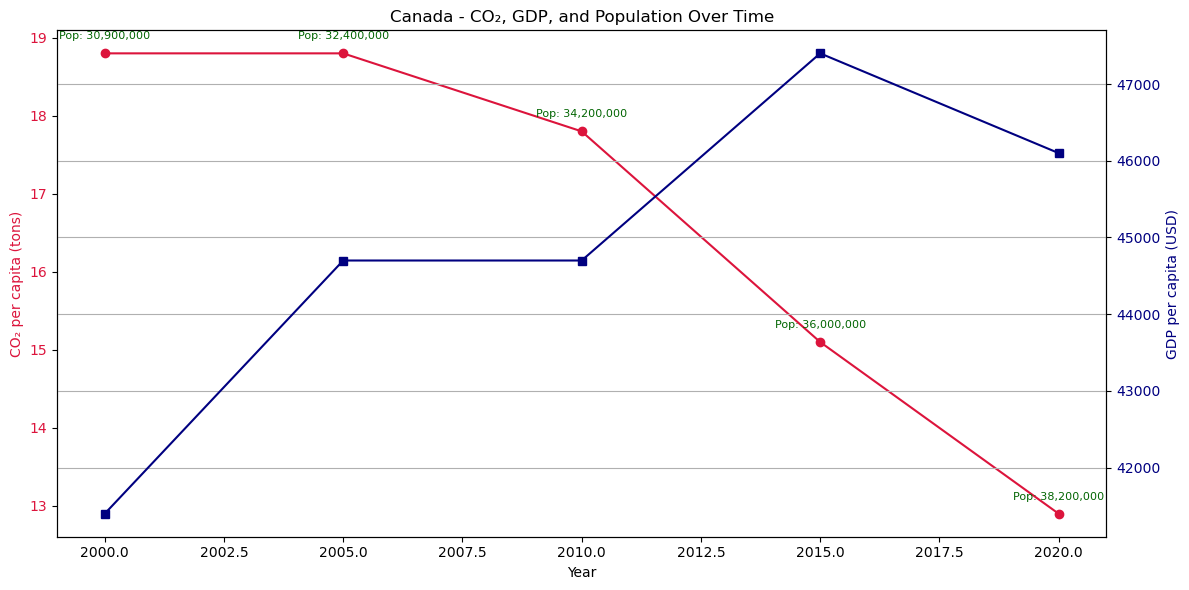

In [ ]:
# Filter for selected countries and years
country = "Canada"
selected_years = [2000, 2005, 2010, 2015, 2020]

filtered = data[(data['Country'] == country) & (data['year'].isin(selected_years))].sort_values(by='year')

if filtered.empty:
    print(f"No data found for {country} in years {selected_years}.")
    
# Plot setup
fig, ax1 = plt.subplots(figsize=(12, 6))

# CO₂ per capita
ax1.plot(filtered['year'], filtered['co2'], color='crimson', marker='o', label='CO₂ per capita (tons)')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO₂ per capita (tons)', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')

# Create a second y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(filtered['year'], filtered['gdp'], color='navy', marker='s', label='GDP per capita ($)')
ax2.set_ylabel('GDP per capita (USD)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

# Add population on third axis using text annotations
for i, row in filtered.iterrows():
    ax1.annotate(f"Pop: {int(row['population']):,}", 
                (row['year'], row['co2']),
                textcoords="offset points", xytext=(0,10),
                ha='center', fontsize=8, color='darkgreen')
plt.title(f"{country} - CO₂, GDP, and Population Over Time")
fig.tight_layout()
plt.grid(True)
plt.show()